In [ ]:
import os
import pandas as pd
from Sequential_Fish.tools import safe_merge_no_duplicates
from Sequential_Fish.analysis.post_processing import Spots_filtering

RUN_PATH = "/home/floric/Documents/SeqfFish/2026-03-24 - HeLa_POLR2_Run17_tiff"

# Visualize Spots

In [ ]:
Gene_map = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Gene_map.feather"))
Detection = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Detection.feather"))
Spots = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Spots.feather"))
Acquisition = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Acquisition.feather"))
Cell = pd.read_feather(os.path.join(RUN_PATH,"result_tables","Cell.feather"))

In [ ]:
# Spots = Spots_filtering(
#     Spots=Spots,
#     Detection=Detection,
#     Cell=Cell,
#     segmentation_filter=False,
#     filter_washout=False
# )

Detection = safe_merge_no_duplicates(
    Detection,
    Acquisition,
    on= ['acquisition_id'],
    keys=['cycle','location', 'fish_reodered_shape']
)

Detection = safe_merge_no_duplicates(
    Detection,
    Gene_map,
    on= ['cycle','color_id'],
    keys=['target']
)

Spots =safe_merge_no_duplicates(
    Spots,
    Detection,
    on= ['detection_id','color_id'],
    keys= ['location','target', 'voxel_size', 'fish_reodered_shape']
)

# Spots = safe_merge_no_duplicates(
#     Spots,
#     Cell.rename(columns={'label' : 'cell_label'}),
#     on=['acquisition_id','detection_id','cell_label'],
#     keys=['cell_id']
# )

In [ ]:
Spots_nowashout = Spots.loc[~Spots["is_washout"]]
Spots_nowashout = Spots_nowashout[Spots_nowashout["cell_label"] != 0]
Spots_nowashout.groupby(["location","color_id","target"]).agg({
    "cell_label" : lambda x : len(pd.unique(x)),
    "spot_id" : "count",
    }).sort_index()

cell_label  spot_id
location    color_id target                              
Location-01 0        POLR2A                   41    10817
                     POLR2A_endcycle          41     2901
                     POLR2B                   41     1901
                     POLR2C                   41     2373
                     POLR2E                   41     3841
...                                          ...      ...
Location-30 1        POLR2I                   29      790
                     POLR2J                   29     3004
                     POLR2K                   29      858
                     POLR2L                   29     2224
                     PRPF8_endcycle           29     2655

[480 rows x 2 columns]

In [ ]:
import matplotlib.pyplot as plt
from my_plots.super_plot import distribution_super_plot

In [ ]:
data = Spots_nowashout.groupby(["target","location","cell_label"])["spot_id"].count().squeeze()
data = data.groupby(["target","location"]).apply(list)
data.index = list(zip(
    data.index.get_level_values(0).astype(str),
    data.index.get_level_values(1),
    ))
data = data.sort_index(axis=0)
data

(ANXA5, Location-01)             [68, 190, 169, 282, 247, 206, 424, 199, 146, 1...
(ANXA5, Location-02)             [218, 216, 276, 165, 184, 205, 132, 213, 149, ...
(ANXA5, Location-03)             [252, 68, 173, 262, 123, 143, 212, 247, 162, 9...
(ANXA5, Location-04)             [239, 211, 179, 258, 242, 220, 235, 176, 201, ...
(ANXA5, Location-05)             [89, 129, 97, 311, 236, 109, 228, 5, 300, 256,...
                                                       ...                        
(PRPF8_endcycle, Location-26)    [67, 74, 114, 114, 68, 69, 97, 73, 88, 73, 81,...
(PRPF8_endcycle, Location-27)    [32, 73, 150, 68, 80, 85, 77, 131, 111, 95, 85...
(PRPF8_endcycle, Location-28)    [25, 65, 107, 89, 111, 92, 129, 87, 64, 121, 5...
(PRPF8_endcycle, Location-29)    [103, 82, 102, 106, 80, 67, 72, 77, 65, 66, 64...
(PRPF8_endcycle, Location-30)    [91, 90, 79, 83, 71, 53, 78, 98, 79, 48, 69, 7...
Name: spot_id, Length: 480, dtype: object

ValueError: Length of colors and distributions must match.

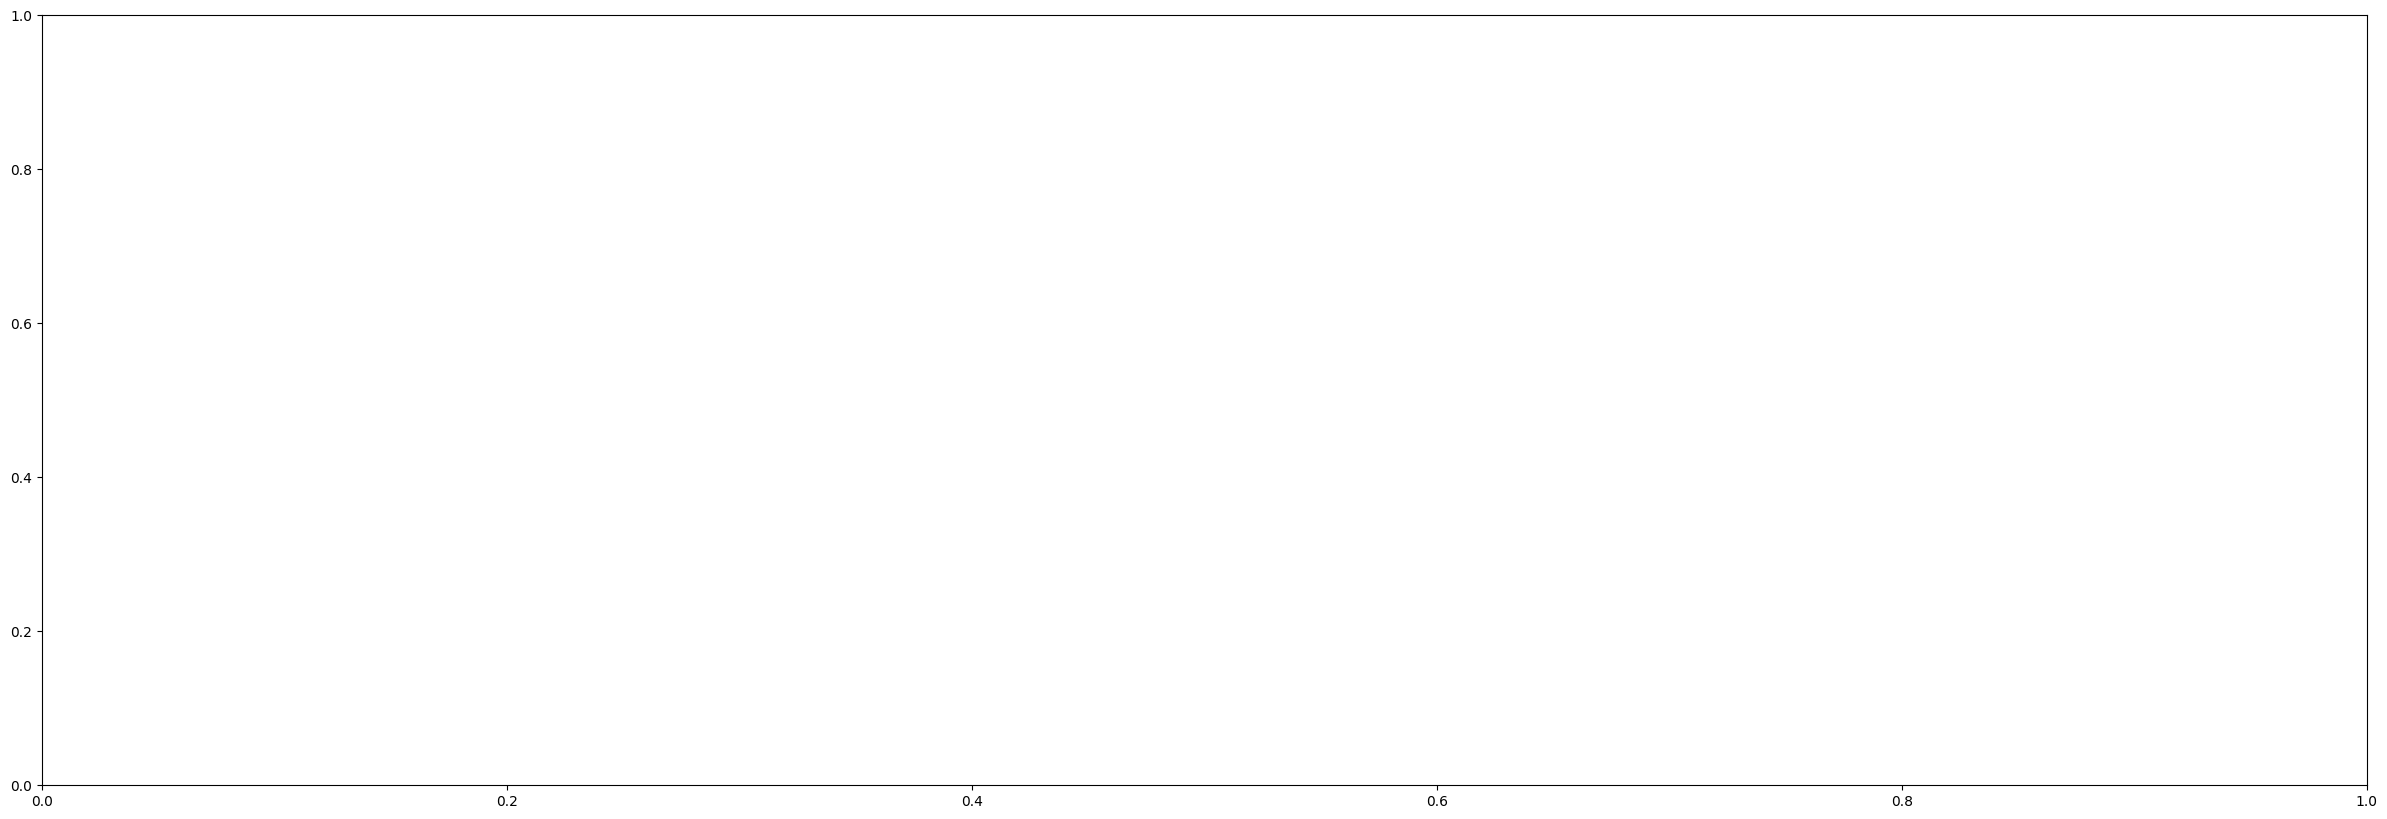

In [ ]:
fig = plt.figure(figsize=(30,10))
ax = fig.gca()
ax = distribution_super_plot(
    data= data,
    ax=ax
)